# Mount tới Google colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import các thư viện

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Cấu hình các thông số

In [3]:
PATH = '/content/drive/MyDrive/UIT/CS523/TRAIN.xlsx'
learning_rate = 1e-3
epochs = 1000

# Đọc dữ liệu

In [4]:
df = pd.read_excel(PATH)

In [5]:
X = torch.tensor(df['midterm'], dtype=torch.float32)
Y = torch.tensor(df['final'], dtype=torch.float32)
X = X.reshape(-1,1)
Y = Y.reshape(-1,1)

In [6]:
W = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)
b = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)

# Training model

In [7]:
loss_history = []

for _ in range(epochs):
  Y_predicted = X @ W + b
  Z = Y - Y_predicted
  Loss = Z ** 2
  MSE = Loss.mean()
  MSE.backward()

  with torch.no_grad():
    W -= learning_rate * W.grad
    b -= learning_rate * b.grad

  W.grad.zero_()
  b.grad.zero_()

  loss_history.append(MSE.item())

In [8]:
print(W, b)

tensor([[0.9681]], requires_grad=True) tensor([[0.8780]], requires_grad=True)


# Đánh giá mô hình

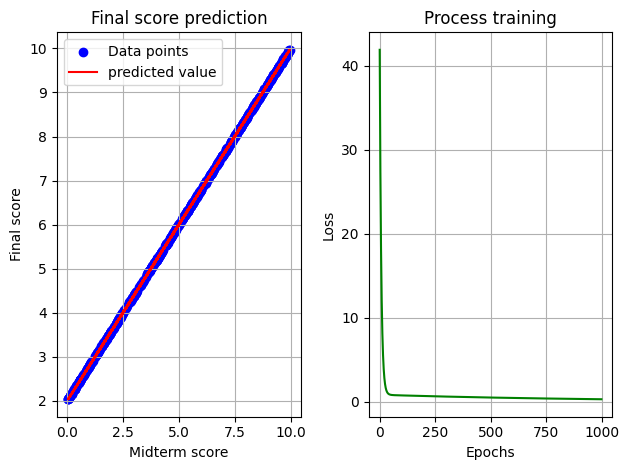

In [9]:
plt.subplot(1, 2, )
plt.scatter(X.numpy(), Y.numpy(), color='blue', label='Data points')
plt.plot(X.numpy(), Y.numpy(), color='red', label='predicted value')
plt.title('Final score prediction')
plt.xlabel('Midterm score')
plt.ylabel('Final score')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss_history, color='green')
plt.title('Process training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()

# Inference

In [10]:
def predict_final_score(midterm_score):
    with torch.no_grad():
        x_new = torch.tensor([[float(midterm_score)]])
        y_pred = x_new @ W + b
        return y_pred.item()

In [11]:
new_students_midterms = [3.5, 6.5, 8.5]
for score in new_students_midterms:
    final_score = predict_final_score(score)

    print(f"Midterm score: {score:.1f} --> Final score prediction: {final_score:.2f}")

Midterm score: 3.5 --> Final score prediction: 4.27
Midterm score: 6.5 --> Final score prediction: 7.17
Midterm score: 8.5 --> Final score prediction: 9.11
